In [1]:
#!pip install dtreeviz graphviz ipykernel cairosvg

In [2]:
import dtreeviz
import graphviz
print('dtreeviz import 성공')
print('graphviz import 성공')

dtreeviz import 성공
graphviz import 성공


In [3]:
import os

graphviz_bin = r'C:\Program Files\Graphviz\bin'

os.environ['PATH'] = graphviz_bin + os.pathsep + os.environ['PATH']

print('Graphviz PATH 추가 완료:')
print(graphviz_bin)

Graphviz PATH 추가 완료:
C:\Program Files\Graphviz\bin


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

mpl.rcParams['svg.fonttype'] = 'none'

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('jeju_bus.csv')
print('jeju_bus.csv를 정상적으로 불러왔습니다.')

jeju_bus.csv를 정상적으로 불러왔습니다.


In [7]:
df.head()

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64


In [8]:
df_model = df.copy()

In [9]:
target_col = 'next_arrive_time'

In [10]:
df_model[['date', 'now_arrive_time']].head()

,date,now_arrive_time
0,2019-10-15,06시
1,2019-10-15,06시
2,2019-10-15,06시
3,2019-10-15,06시
4,2019-10-15,07시


In [11]:
df_model['date'] = pd.to_datetime(df_model['date'], errors = 'coerce')

df_model['year'] = df_model['date'].dt.year
df_model['month'] = df_model['date'].dt.month
df_model['day'] = df_model['date'].dt.day
df_model['dayofweek'] = df_model['date'].dt.dayofweek

df_model['now_hour'] = df_model['now_arrive_time'].astype(str).str.extract(r'(\d+)').astype(float)

df_model[['date', 'day', 'dayofweek', 'now_arrive_time', 'now_hour']].head()

,date,day,dayofweek,now_arrive_time,now_hour
0,2019-10-15,15,1,06시,6.0
1,2019-10-15,15,1,06시,6.0
2,2019-10-15,15,1,06시,6.0
3,2019-10-15,15,1,06시,6.0
4,2019-10-15,15,1,07시,7.0


In [12]:
def calculate_distance_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2        
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

In [13]:
reference_points = {
    'up'    : (33.506286, 126.490312),
    'down'  : (33.246742, 126.562387),
    'right' : (33.493521, 126.895326),
    'center': (33.379724, 126.545315)
}

In [14]:
def assign_region_info(data, lat_col, lon_col):
    up_lat, up_lon = reference_points['up']
    down_lat, down_lon = reference_points['down']
    right_lat, right_lon = reference_points['right']
    center_lat, center_lon = reference_points['center']

    distance_to_up = calculate_distance_km(data[lat_col], data[lon_col], up_lat, up_lon)
    distance_to_down = calculate_distance_km(data[lat_col], data[lon_col], down_lat, down_lon)
    distance_to_right = calculate_distance_km(data[lat_col], data[lon_col], right_lat, right_lon)
    distance_to_center = calculate_distance_km(data[lat_col], data[lon_col], center_lat, center_lon)

    distance_table = pd.DataFrame({
        'up': distance_to_up,
        'down': distance_to_down,
        'right': distance_to_right,
        'center': distance_to_center        
    }, index = data.index)

    nearest_region = distance_table.idxmin(axis = 1)

    result = pd.DataFrame({
        'dist_name': nearest_region,
        'dist_to_up': distance_to_up,
        'dist_to_down': distance_to_down,
        'dist_to_right': distance_to_right,
        'dist_to_center': distance_to_center
    }, index = data.index)

    return result

In [15]:
now_region_info = assign_region_info(
    df_model,
    'now_latitude',
    'now_longitude'
)

now_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,7.962505,23.319056,32.135034,8.532122
1,up,8.003869,23.473015,31.905930,8.710701
2,up,8.158338,23.582519,31.583874,8.861671
3,up,5.774762,25.961685,32.635035,11.118256
4,up,2.332803,27.295447,37.141639,12.673969


In [16]:
next_region_info = assign_region_info(
    df_model,
    'next_latitude',
    'next_longitude'
)

next_region_info.head()

,dist_name,dist_to_up,dist_to_down,dist_to_right,dist_to_center
0,up,8.003869,23.473015,31.905930,8.710701
1,up,8.158338,23.582519,31.583874,8.861671
2,up,8.387595,23.701416,31.175511,9.041978
3,up,5.429627,26.539110,32.693959,11.692688
4,up,2.276139,27.400941,37.514443,12.832868


In [17]:
df_model['now_dist_name'] = now_region_info['dist_name']
df_model['now_dist_to_up'] = now_region_info['dist_to_up']
df_model['now_dist_to_down'] = now_region_info['dist_to_down']
df_model['now_dist_to_right'] = now_region_info['dist_to_right']
df_model['now_dist_to_center'] = now_region_info['dist_to_center']

df_model.iloc[:,19:]

,now_dist_name,now_dist_to_up,now_dist_to_down,now_dist_to_right,now_dist_to_center
0,up,7.962505,23.319056,32.135034,8.532122
1,up,8.003869,23.473015,31.905930,8.710701
2,up,8.158338,23.582519,31.583874,8.861671
3,up,5.774762,25.961685,32.635035,11.118256
4,up,2.332803,27.295447,37.141639,12.673969
...,...,...,...,...,...
210452,down,29.005930,1.724127,39.624369,14.101369
210453,down,29.560001,0.607018,40.775774,14.739550
210454,down,29.024374,0.604451,41.106369,14.282445
210455,down,29.096335,0.550141,41.217986,14.365152


In [18]:
df_model['next_dist_name'] = next_region_info['dist_name']
df_model['next_dist_to_up'] = next_region_info['dist_to_up']
df_model['next_dist_to_down'] = next_region_info['dist_to_down']
df_model['next_dist_to_right'] = next_region_info['dist_to_right']
df_model['next_dist_to_center'] = next_region_info['dist_to_center']

df_model.iloc[:,24:]

,next_dist_name,next_dist_to_up,next_dist_to_down,next_dist_to_right,next_dist_to_center
0,up,8.003869,23.473015,31.905930,8.710701
1,up,8.158338,23.582519,31.583874,8.861671
2,up,8.387595,23.701416,31.175511,9.041978
3,up,5.429627,26.539110,32.693959,11.692688
4,up,2.276139,27.400941,37.514443,12.832868
...,...,...,...,...,...
210452,down,29.345088,1.256942,40.123236,14.468773
210453,down,29.377265,0.471628,40.867894,14.578870
210454,down,29.096335,0.550141,41.217986,14.365152
210455,down,29.237779,0.505603,41.437302,14.528214


In [19]:
df_model['dist_segment_name'] = (
    df_model['now_dist_name'].astype(str)
    + ' → '
    + df_model['next_dist_name'].astype(str)
)

df_model.iloc[:,29]

0             up → up
1             up → up
2             up → up
3             up → up
4             up → up
             ...     
210452    down → down
210453    down → down
210454    down → down
210455    down → down
210456    down → down
Name: dist_segment_name, Length: 210457, dtype: str

In [20]:
print('dist_segment_name 고유값 개수:', df_model['dist_segment_name'].nunique())
df_model['dist_segment_name'].value_counts()

dist_segment_name 고유값 개수: 12


dist_segment_name
up → up            121131
down → down         48377
right → right       34032
center → center      5512
center → up           321
right → up            276
up → center           207
down → right          144
up → right            137
right → down          134
down → center          95
center → down          91
Name: count, dtype: int64

In [21]:
selected_numeric_features = [
     'distance', 
     'day',  
     'dayofweek',
     'now_hour',
     'now_dist_to_up',
     'now_dist_to_down',
     'now_dist_to_right',
     'now_dist_to_center',
     'next_dist_to_up',
     'next_dist_to_down',
     'next_dist_to_right',
     'next_dist_to_center'
]

In [22]:
selected_categorical_features = [
     'route_nm',
     'now_station',
     'next_station',
     'dist_segment_name'
]

In [23]:
selected_features = selected_numeric_features + selected_categorical_features

selected_features

['distance',
 'day',
 'dayofweek',
 'now_hour',
 'now_dist_to_up',
 'now_dist_to_down',
 'now_dist_to_right',
 'now_dist_to_center',
 'next_dist_to_up',
 'next_dist_to_down',
 'next_dist_to_right',
 'next_dist_to_center',
 'route_nm',
 'now_station',
 'next_station',
 'dist_segment_name']

In [24]:
upper_1pct = df_model[target_col].quantile(0.99)

upper_1pct

np.float64(340.0)

In [25]:
df_model_selected = df_model[df_model[target_col] <= upper_1pct].copy()

print('원본 데이터 행 수:',len(df_model))
print('t상위 1% target 제거 후 행 수',len(df_model_selected))
print('제거된 행 수:',len(df_model) - len(df_model_selected))
print('상위 1% 제거 기준값:', upper_1pct)

원본 데이터 행 수: 210457
t상위 1% target 제거 후 행 수 208355
제거된 행 수: 2102
상위 1% 제거 기준값: 340.0


In [26]:
X = df_model_selected[selected_features]
y = df_model_selected[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state= 42
)

print('학습용 크기:', X_train.shape, '/ 검증용 크기:', X_test.shape)

학습용 크기: (166684, 16) / 검증용 크기: (41671, 16)


In [27]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown = 'ignore'), selected_categorical_features),
    ],
    remainder = 'passthrough',
)

print('전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)')

전처리기(preprocessor) 준비 완료 (앞 노트북과 동일한 구성)


In [28]:
def evaluate_regression_model(model_name, description, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f'[{model_name}] MAE : {mae:.4f} | RMSE: {rmse:.4f}')

    return {
        'model_name': model_name,
        'description': description,
        'MAE': mae,
        'RMSE': rmse
    }

In [29]:
def train_xgb_pipeline(model_name, description, xgb_params):
    xgb_model = XGBRegressor(
        objective = 'reg:squarederror',
        random_state = 42,
        n_jobs = -1,
        **xgb_params
    )

    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', xgb_model),
    ])

    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    evaluation = evaluate_regression_model(
        model_name = model_name,
        description = description,
        y_true = y_test,
        y_pred = y_pred
    )

    return {
        'model_name': model_name,
        'pipeline': model_pipeline,
        'y_pred': y_pred,
        'evaluation': evaluation,
    }

In [30]:
param_distributions = {
    'model__max_depth': [3, 5, 7, 9],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__n_estimators': [200, 300, 400],
    'model__subsample':[0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
}

scoring = 'neg_mean_absolute_error'

print('탐색 대상 파라미터 수:', len(param_distributions))

탐색 대상 파라미터 수: 5


In [31]:
search_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs = 1,
    ))
])

In [32]:
random_search = RandomizedSearchCV(
    estimator = search_model,
    param_distributions = param_distributions,
    n_iter = 25,
    scoring = 'neg_mean_absolute_error',
    cv = 5,
    random_state = 42,
    n_jobs = -1,
    verbose = 1,
)

In [33]:
start_time = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f'RandomizedSearchCV 완료. 소요 시간: {elapsed:.1f}초')

Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomizedSearchCV 완료. 소요 시간: 257.8초


In [34]:
# 교차검증 기준 가장 좋았던 하이퍼파라미터 조합
random_search.best_params_

# 교차검증 기준 가장 좋았던 점수(음수 MAE 형태)
random_search.best_score_

# 음수 MAE를 양수 MAE로 변환해 해석합니다.(train 내부 교차검증 결과)
best_cv_mae = -random_search.best_score_
print(f'best_cv_mae (train 내부 교차검증 MAE): {best_cv_mae:.4f}')

best_cv_mae (train 내부 교차검증 MAE): 18.9604


In [36]:
best_model = random_search.best_estimator_

In [37]:
best_preprocessor = best_model.named_steps['preprocessor']
best_xgb_model = best_model.named_steps['model']

print('최적 모델 Pipeline  단계:', list(best_model.named_steps.keys()))

최적 모델 Pipeline  단계: ['preprocessor', 'model']


In [38]:
transformed_feature_names = best_preprocessor.get_feature_names_out()

print('전처리 후 feature 개수:', len(transformed_feature_names))
print('XGBoost feature importance 개수:', len(best_xgb_model.feature_importances_))

전처리 후 feature 개수: 743
XGBoost feature importance 개수: 743


In [39]:
feature_importance_df = pd.DataFrame({
    'feature': transformed_feature_names,
    'importance': best_xgb_model.feature_importances_
})
feature_importance_df = feature_importance_df.sort_values(
    'importance', ascending=False
).reset_index(drop=True)

print(feature_importance_df.head(20))

                                feature  importance
0    cat__next_station_제주중앙여자고등학교(아라방면)    0.063205
1   cat__now_station_성산환승정류장(고성리 회전교차로)    0.047220
2            remainder__next_dist_to_up    0.036898
3                  cat__now_station_원노형    0.031817
4    cat__next_station_제주중앙여자고등학교(광양방면)    0.031475
5             cat__now_station_농협 하나로마트    0.028281
6                 cat__next_station_성판악    0.027448
7                   remainder__distance    0.023465
8                  cat__now_station_성판악    0.021725
9        cat__dist_segment_name_up → up    0.018782
10                cat__now_station_교래입구    0.018678
11               cat__now_station_월성 마을    0.017612
12                cat__next_station_입석동    0.016900
13             cat__now_station_고성리제주은행    0.013826
14      cat__next_station_제주국제공항(구제주방면)    0.013373
15         remainder__next_dist_to_down    0.011034
16     cat__now_station_제주여자중고등학교(광양방면)    0.010025
17                cat__now_station_보성시장    0.009772
18          

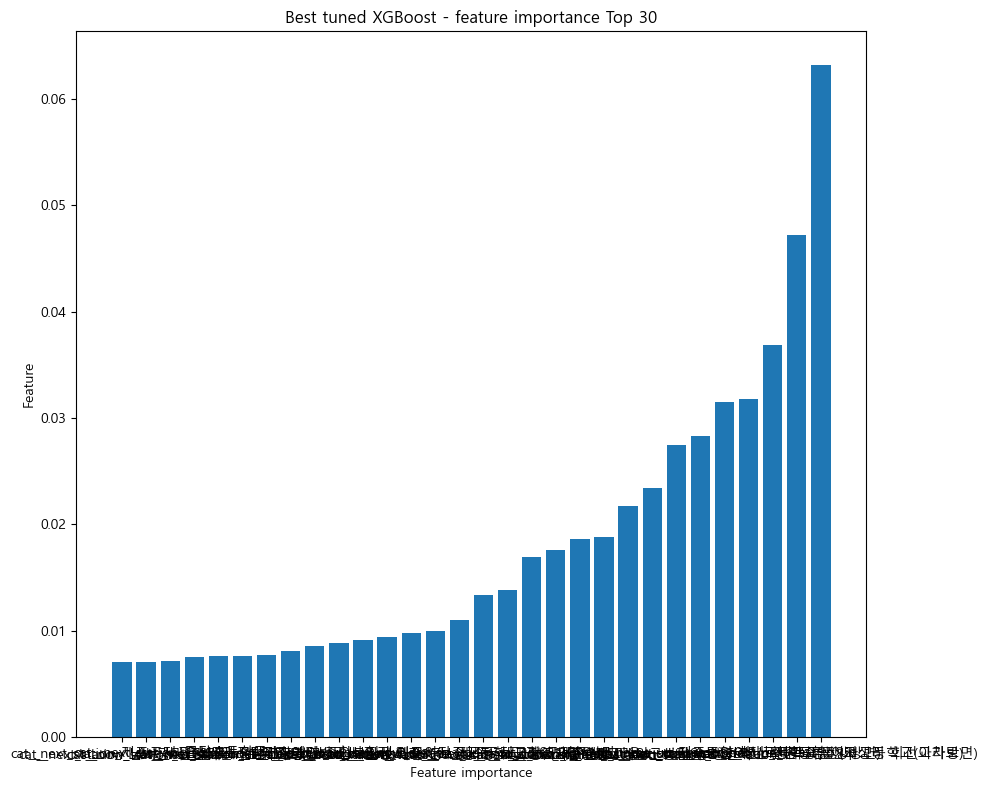

In [40]:
top_n = 30

top_importance_df = feature_importance_df.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 8))
plt.bar(top_importance_df['feature'], top_importance_df['importance'])
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('Best tuned XGBoost - feature importance Top 30')
plt.tight_layout()
plt.show()

In [44]:
def get_original_feature_name(transformed_name, categorical_features, numeric_features):
    if transformed_name.startswith('cat__'):
        name = transformed_name.replace('cat__','',1)
        for col in categorical_features:
            if name == col or name.startswith(col + '_'):
                return col
        return name

    if transformed_name.startswith('remainder__'):
        return transformed_name.replace('remainder__','',1)

    return transformed_name

In [45]:
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    feature_importance_df['original_feature'] = feature_importance_df['feature'].apply(
        lambda x: get_original_feature_name(
            x,
            selected_categorical_features,
            selected_numeric_features,
        )
    )

    grouped_importance_df = (
        feature_importance_df
        .groupby('original_feature', as_index = False)
        .sum()
        .sort_values('importance', ascending = False)
        .reset_index(drop=True)        
    )

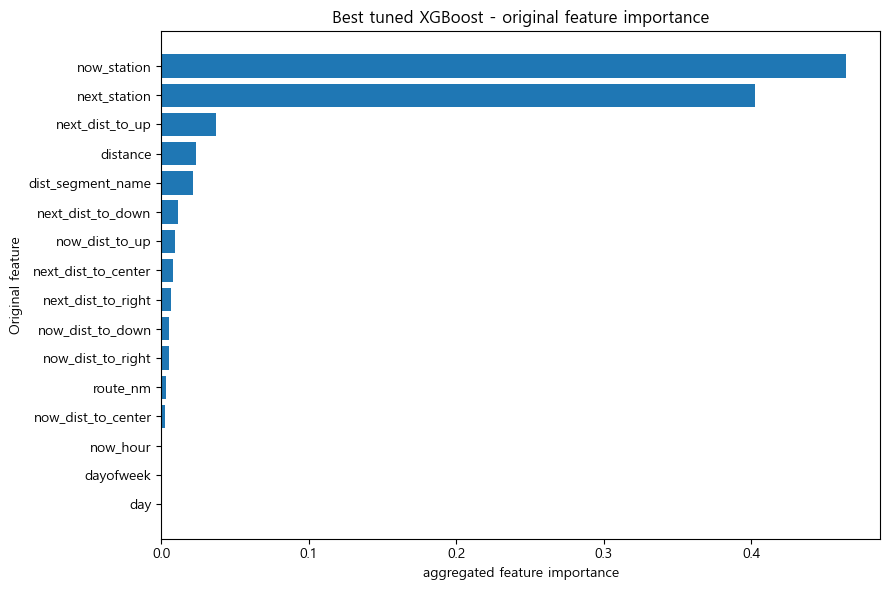

In [46]:
if len(transformed_feature_names) == len(best_xgb_model.feature_importances_):
    plot_grouped_df = grouped_importance_df.sort_values('importance')

    plt.figure(figsize=(9, 6))
    plt.barh(plot_grouped_df['original_feature'], plot_grouped_df['importance'])
    plt.xlabel('aggregated feature importance')
    plt.ylabel('Original feature')
    plt.title('Best tuned XGBoost - original feature importance')
    plt.tight_layout()
    plt.show()